# Student Dropout Prediction using Machine Learning

### Internship Project

Prepared by: Gourav Layek

Enrollment No:24STUCHH010899

Email:gouravlayek1@gmail.com

Dataset: EduSpark Student Dropout Dataset

#Importing Libraries

In [ ]:
import pandas as pd

file_id = "1yKnd2a1DeM6F5Q0ch6x_eOHzfm1J9iFk"

url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)

df.head()

,Academic Score,Attendance (%),Course Engagement Score (0-10),Family Income,Parental Education,Gender,Region,Dropout (Yes/No)
0,49.673992,89.477501,3.396433,288691.722981,Postgraduate,Male,Urban,No
1,52.747804,71.671186,5.848657,85826.441377,High School,Male,Urban,No
2,97.282936,92.333342,4.325247,258690.163928,NaN,Male,Semi-Urban,No
3,66.784044,82.161893,7.192235,231826.400878,High School,Male,Semi-Urban,No
4,68.178995,56.999065,7.895088,292199.685156,High School,Female,Semi-Urban,No


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Dataset Overview

In [ ]:
df.sample(5)

,Academic Score,Attendance (%),Course Engagement Score (0-10),Family Income,Parental Education,Gender,Region,Dropout (Yes/No)
588,77.756908,72.077426,7.932566,345687.532187,NaN,Male,Semi-Urban,No
971,67.992661,81.994589,0.328204,392651.431082,Postgraduate,Male,Urban,No
538,70.783983,83.194230,5.234618,244639.182794,NaN,Female,Rural,No
688,45.973711,89.381861,3.724130,299590.985347,High School,Male,Rural,No
532,69.636366,87.092344,1.616286,196584.641647,High School,Male,Urban,No


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
df.columns
df.info()
df.dtypes
df.describe()
df.isnull().sum()
df.duplicated().sum()

Rows : 1000
Columns : 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Academic Score                  1000 non-null   float64
 1   Attendance (%)                  1000 non-null   float64
 2   Course Engagement Score (0-10)  1000 non-null   float64
 3   Family Income                   1000 non-null   float64
 4   Parental Education              838 non-null    object 
 5   Gender                          1000 non-null   object 
 6   Region                          1000 non-null   object 
 7   Dropout (Yes/No)                1000 non-null   object 
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


np.int64(0)

In [ ]:
df.head()

,Academic Score,Attendance (%),Course Engagement Score (0-10),Family Income,Parental Education,Gender,Region,Dropout (Yes/No)
0,49.673992,89.477501,3.396433,288691.722981,Postgraduate,Male,Urban,No
1,52.747804,71.671186,5.848657,85826.441377,High School,Male,Urban,No
2,97.282936,92.333342,4.325247,258690.163928,NaN,Male,Semi-Urban,No
3,66.784044,82.161893,7.192235,231826.400878,High School,Male,Semi-Urban,No
4,68.178995,56.999065,7.895088,292199.685156,High School,Female,Semi-Urban,No


#Exploratory Data Analysis (EDA)

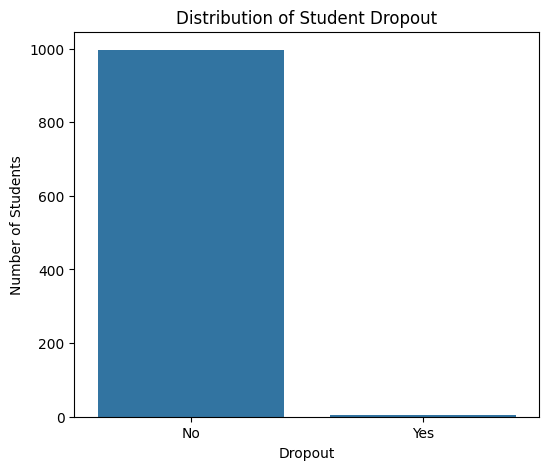

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='Dropout (Yes/No)', data=df)

plt.title("Distribution of Student Dropout")
plt.xlabel("Dropout")
plt.ylabel("Number of Students")

plt.show()

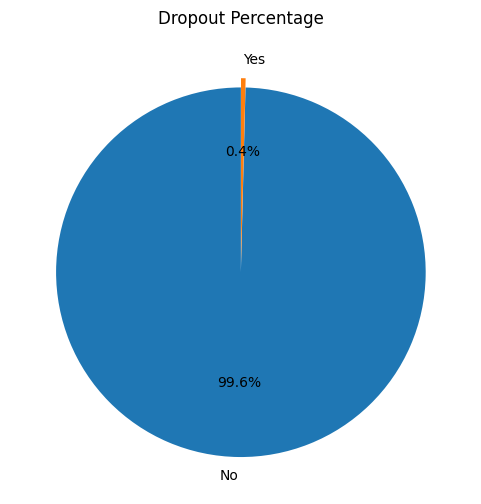

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    df['Dropout (Yes/No)'].value_counts(),
    labels=df['Dropout (Yes/No)'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05,0]
)

plt.title("Dropout Percentage")
plt.show()

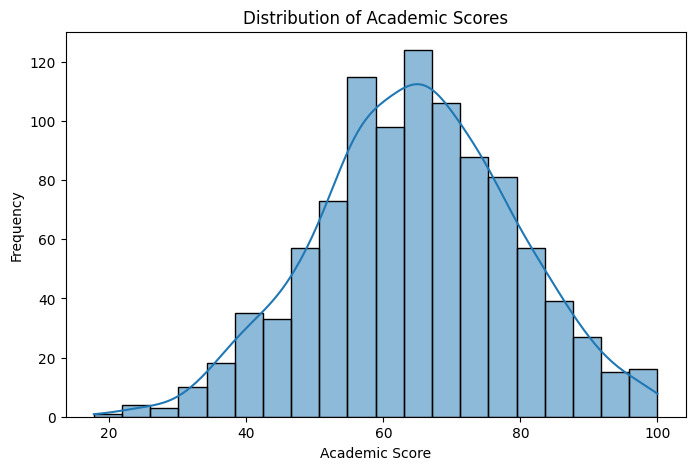

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Academic Score'], bins=20, kde=True)

plt.title("Distribution of Academic Scores")
plt.xlabel("Academic Score")
plt.ylabel("Frequency")

plt.show()

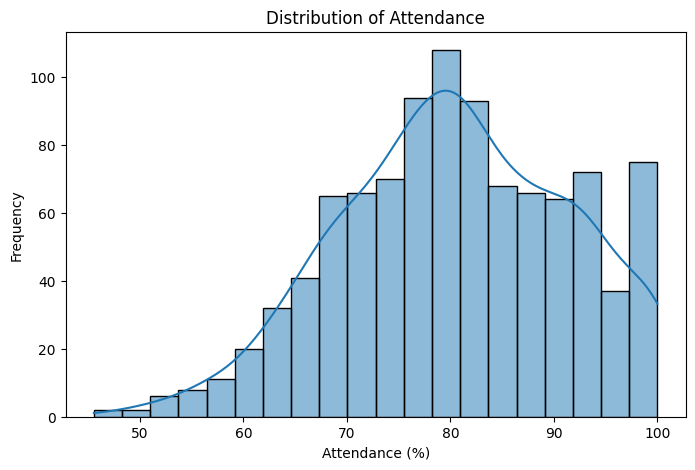

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Attendance (%)'], bins=20, kde=True)

plt.title("Distribution of Attendance")
plt.xlabel("Attendance (%)")
plt.ylabel("Frequency")

plt.show()

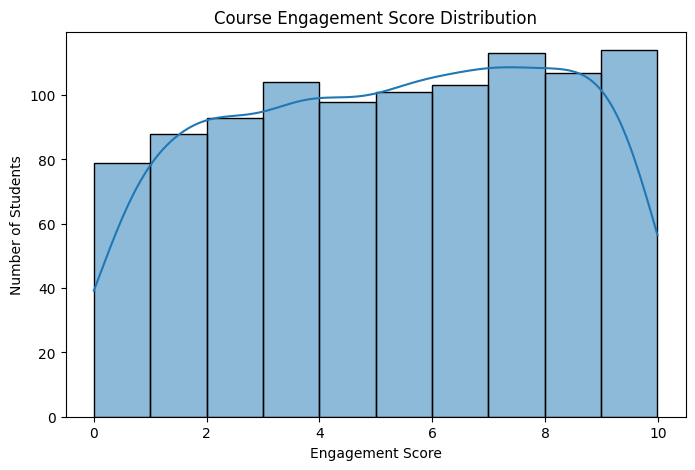

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Course Engagement Score (0-10)'], bins=10, kde=True)

plt.title("Course Engagement Score Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Students")

plt.show()

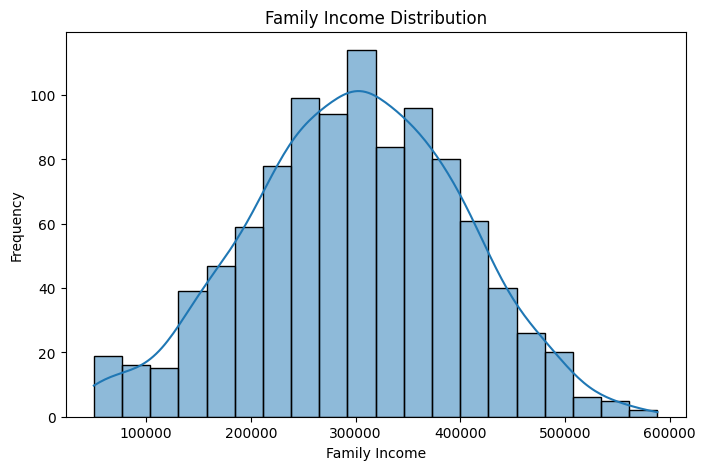

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Family Income'], bins=20, kde=True)

plt.title("Family Income Distribution")
plt.xlabel("Family Income")
plt.ylabel("Frequency")

plt.show()

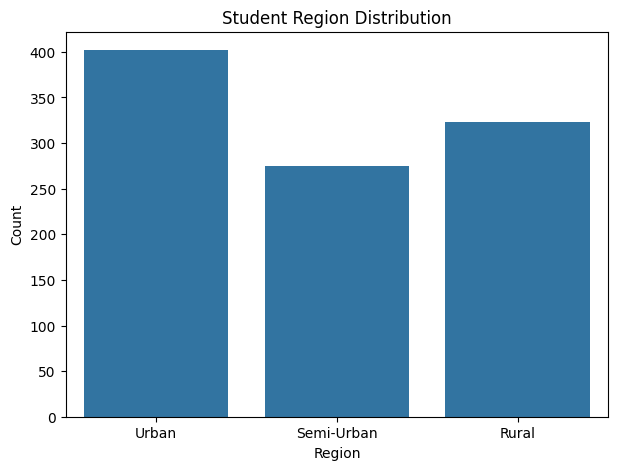

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x='Region', data=df)

plt.title("Student Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")

plt.show()

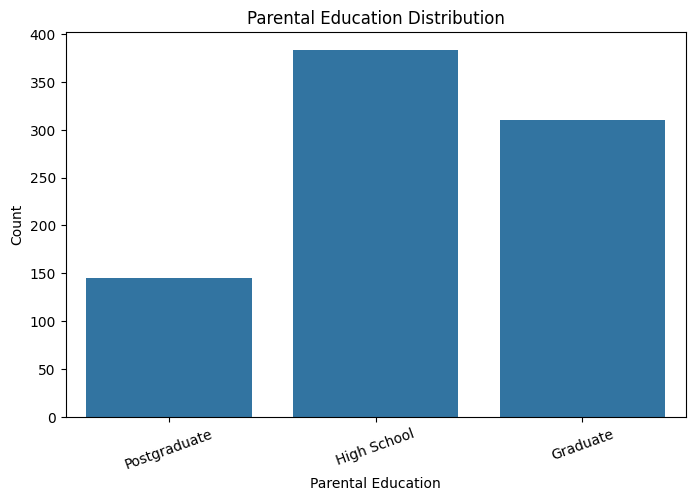

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Parental Education', data=df)

plt.title("Parental Education Distribution")
plt.xlabel("Parental Education")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

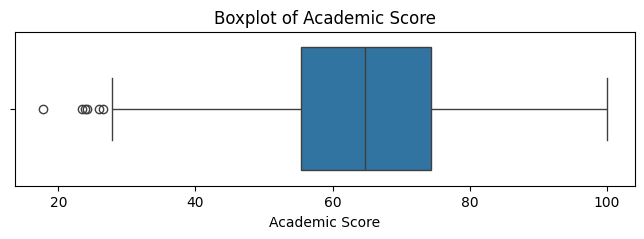

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Academic Score'])

plt.title("Boxplot of Academic Score")

plt.show()

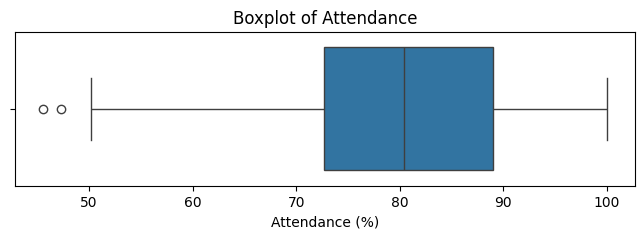

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Attendance (%)'])

plt.title("Boxplot of Attendance")

plt.show()

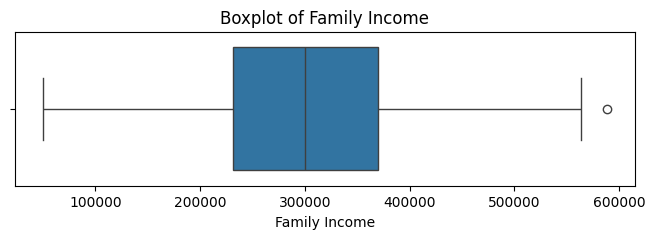

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Family Income'])

plt.title("Boxplot of Family Income")

plt.show()

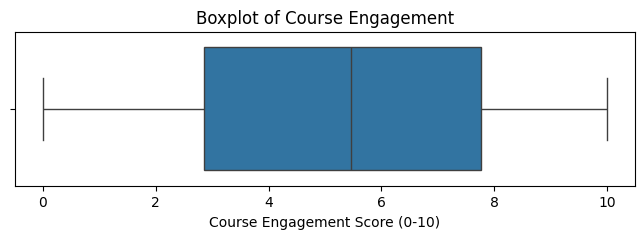

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Course Engagement Score (0-10)'])

plt.title("Boxplot of Course Engagement")

plt.show()

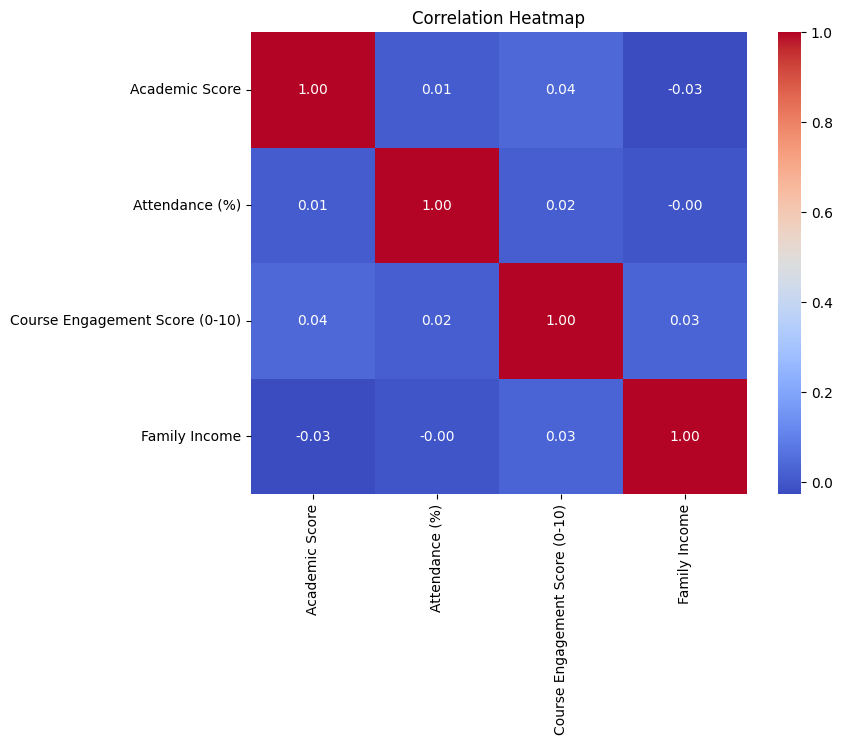

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

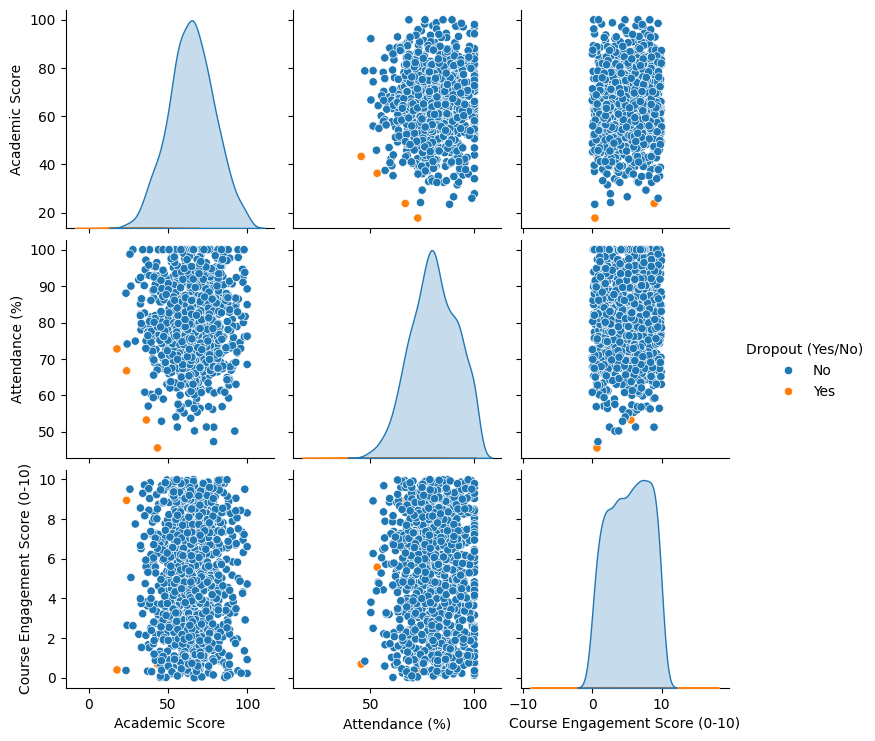

In [ ]:
sns.pairplot(
    df,
    hue='Dropout (Yes/No)',
    vars=[
        'Academic Score',
        'Attendance (%)',
        'Course Engagement Score (0-10)'
    ]
)

plt.show()

# Data Preprocessing

In [ ]:
df.select_dtypes(include='object').columns

Index(['Parental Education', 'Gender', 'Region', 'Dropout (Yes/No)'], dtype='object')

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


Parental Education
['Postgraduate' 'High School' nan 'Graduate']

Gender
['Male' 'Female']

Region
['Urban' 'Semi-Urban' 'Rural']

Dropout (Yes/No)
['No' 'Yes']


In [ ]:
df['Dropout (Yes/No)'] = df['Dropout (Yes/No)'].map({
    'No':0,
    'Yes':1
})


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Parental Education','Gender','Region'],
    drop_first=True
)

In [ ]:
df.head()

,Academic Score,Attendance (%),Course Engagement Score (0-10),Family Income,Dropout (Yes/No),Parental Education_High School,Parental Education_Postgraduate,Gender_Male,Region_Semi-Urban,Region_Urban
0,49.673992,89.477501,3.396433,288691.722981,0,False,True,True,False,True
1,52.747804,71.671186,5.848657,85826.441377,0,True,False,True,False,True
2,97.282936,92.333342,4.325247,258690.163928,0,False,False,True,True,False
3,66.784044,82.161893,7.192235,231826.400878,0,True,False,True,True,False
4,68.178995,56.999065,7.895088,292199.685156,0,True,False,False,True,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Academic Score                   1000 non-null   float64
 1   Attendance (%)                   1000 non-null   float64
 2   Course Engagement Score (0-10)   1000 non-null   float64
 3   Family Income                    1000 non-null   float64
 4   Dropout (Yes/No)                 1000 non-null   int64  
 5   Parental Education_High School   1000 non-null   bool   
 6   Parental Education_Postgraduate  1000 non-null   bool   
 7   Gender_Male                      1000 non-null   bool   
 8   Region_Semi-Urban                1000 non-null   bool   
 9   Region_Urban                     1000 non-null   bool   
dtypes: bool(5), float64(4), int64(1)
memory usage: 44.1 KB


In [ ]:
bool_columns = df.select_dtypes(include='bool').columns

df[bool_columns] = df[bool_columns].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Academic Score                   1000 non-null   float64
 1   Attendance (%)                   1000 non-null   float64
 2   Course Engagement Score (0-10)   1000 non-null   float64
 3   Family Income                    1000 non-null   float64
 4   Dropout (Yes/No)                 1000 non-null   int64  
 5   Parental Education_High School   1000 non-null   int64  
 6   Parental Education_Postgraduate  1000 non-null   int64  
 7   Gender_Male                      1000 non-null   int64  
 8   Region_Semi-Urban                1000 non-null   int64  
 9   Region_Urban                     1000 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 78.3 KB


# Define Feature and Target Variables

In [ ]:
X = df.drop('Dropout (Yes/No)', axis=1)

y = df['Dropout (Yes/No)']

In [ ]:
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (1000, 9)
Shape of y : (1000,)


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (800, 9)
Testing Features : (200, 9)
Training Labels : (800,)
Testing Labels : (200,)


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
numerical_columns = [
    'Academic Score',
    'Attendance (%)',
    'Course Engagement Score (0-10)',
    'Family Income'
]

scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [ ]:
X_train.head()

,Academic Score,Attendance (%),Course Engagement Score (0-10),Family Income,Parental Education_High School,Parental Education_Postgraduate,Gender_Male,Region_Semi-Urban,Region_Urban
790,0.345212,0.161329,0.991812,-1.354506,0,0,0,0,0
460,-0.844186,-1.336211,-1.285512,-0.008504,0,0,1,0,1
554,1.320821,0.365492,1.663305,-0.695915,0,1,0,0,0
433,0.189536,-0.498664,1.458830,-0.849146,0,0,1,1,0
757,-0.103598,1.102689,-0.958678,0.364644,0,0,0,1,0


# Model Building

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred = log_model.predict(X_test)

In [ ]:
X = df.drop('Dropout (Yes/No)', axis=1)
y = df['Dropout (Yes/No)']

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy*100:.2f}%")


Accuracy: 1.0
Accuracy: 100.00%


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       199
           1       1.00      1.00      1.00         1

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



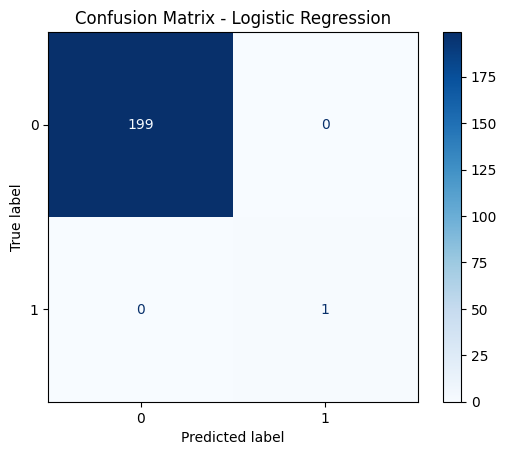

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
print("Training Accuracy:", log_model.score(X_train, y_train))
print("Testing Accuracy :", log_model.score(X_test, y_test))

Training Accuracy: 0.99375
Testing Accuracy : 1.0


## Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


dt_model.fit(X_train, y_train)


y_pred_dt = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy*100:.2f}%")

Decision Tree Accuracy: 98.00%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       199
           1       0.20      1.00      0.33         1

    accuracy                           0.98       200
   macro avg       0.60      0.99      0.66       200
weighted avg       1.00      0.98      0.99       200



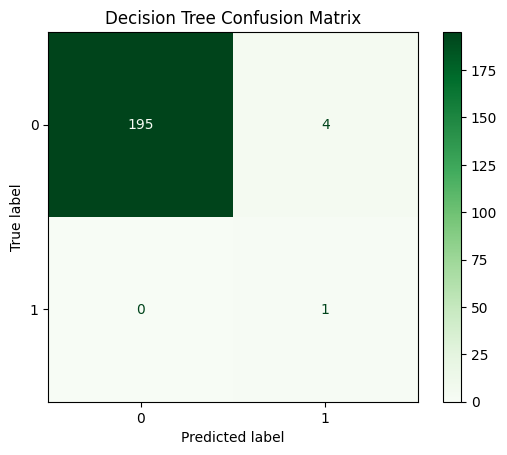

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [ ]:
print("Training Accuracy :", dt_model.score(X_train, y_train))
print("Testing Accuracy  :", dt_model.score(X_test, y_test))

Training Accuracy : 0.99375
Testing Accuracy  : 0.98


## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")

Random Forest Accuracy: 99.50%


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       199
           1       0.00      0.00      0.00         1

    accuracy                           0.99       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.99      0.99      0.99       200



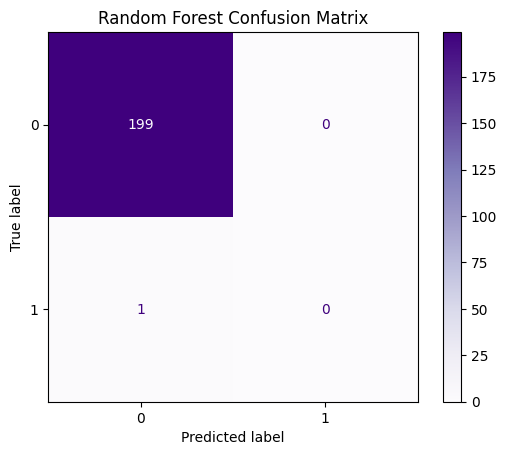

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
print("Training Accuracy :", rf_model.score(X_train, y_train))
print("Testing Accuracy  :", rf_model.score(X_test, y_test))

Training Accuracy : 1.0
Testing Accuracy  : 0.995


# Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy (%)": [
        round(accuracy*100, 2),
        round(dt_accuracy*100, 2),
        round(rf_accuracy*100, 2)
    ]
})

comparison.sort_values(by="Accuracy (%)", ascending=False)

,Model,Accuracy (%)
0,Logistic Regression,100.0
2,Random Forest,99.5
1,Decision Tree,98.0


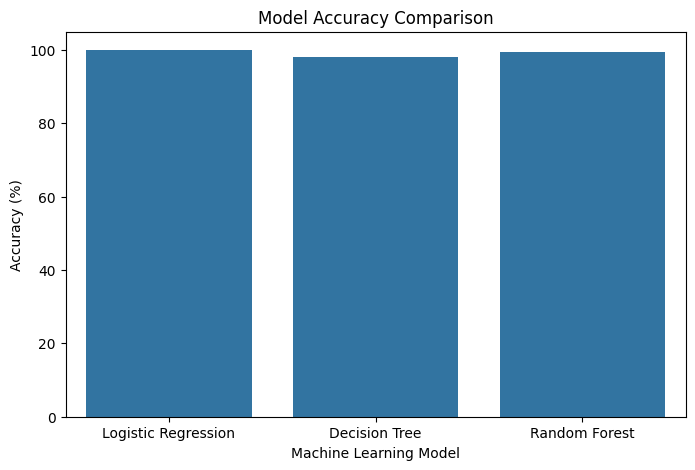

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=comparison
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.show()

# Feature Importance

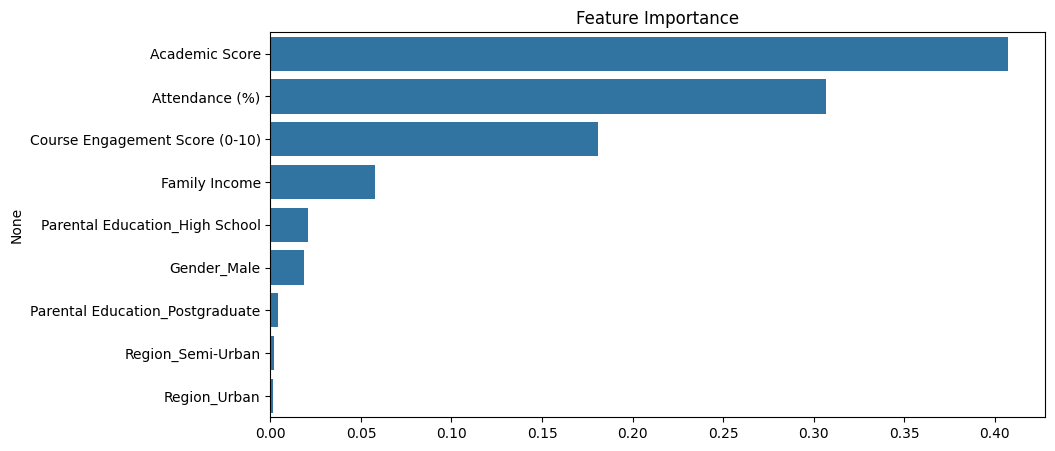

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Feature Importance")

plt.show()

# Prediction on New Student Data

In [ ]:
new_student = pd.DataFrame({
    'Academic Score':[72],
    'Attendance (%)':[78],
    'Course Engagement Score (0-10)':[6],
    'Family Income':[50000],
    'Parental Education_High School':[0],
    'Parental Education_Postgraduate':[1],
    'Gender_Male':[1],
    'Region_Semi-Urban':[0],
    'Region_Urban':[1]
})


In [ ]:
new_student[numerical_columns] = scaler.transform(
    new_student[numerical_columns]
)
prediction = rf_model.predict(new_student)

if prediction[0] == 1:
    print("Prediction: Student is likely to Drop Out.")
else:
    print("Prediction: Student is NOT likely to Drop Out.")

Prediction: Student is NOT likely to Drop Out.


**Conclusion**

This project developed machine learning models to predict student dropout using academic, attendance, engagement, family income, parental education, gender, and region data. Three classification models—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated. Due to the highly imbalanced dataset, accuracy alone was not sufficient for evaluation, and classification reports were analyzed to understand model performance. This project demonstrates how machine learning can assist educational institutions in identifying students at risk and supporting timely interventions.